# Group 2, Notebook_D (shared): the second data source and real-world consequences

**Notebook_D covers Step 7 and answers RQ4.**

> **RQ4:** Among the mainshocks, which ones lead to **real consequences**: deaths, property damage, tsunamis? And which features separate them from the events that left no consequences?

### Why this notebook exists

The USGS catalog in Notebook_A has **exactly 0 consequence columns**. It records where an earthquake happened, how strong and how deep it was, but not whether anyone died, how much damage there was, or whether there was a tsunami.

So RQ4 **cannot be answered with source 1**. Without NOAA/NCEI this question disappears completely. That is the test of whether the second source is **really needed** or was only added to reach the required number of sources.

### The three-tier join chain

NOAA/NCEI is not one table but three tables linked by real foreign keys:

```
USGS ComCat                (source 1: seismic parameters)
   │  matched by time (± 1h, closest in time) within 150 km
   ▼
NCEI Significant Earthquake   id ──┐        (source 2, tier 1: deaths, damage)
                                   │ earthquakeEventId
   NCEI Tsunami Event          id ─┤        (tier 2: maximum wave height, intensity)
                                   │ tsunamiEventId
   NCEI Tsunami Runup ────────────┘         (tier 3: each coastal point, measured water height)
```

Tier 3 is where the volume is: each row is **one coastal point** where the water level was actually measured.

### One thing to say plainly from the start

After restricting to 1990 onward, source 2 has only **111 events**. At that size RQ4 must be **descriptive analysis with hypothesis tests**, and must **not** be forced into a second machine learning model. Doing that would fall straight into the small-n trap that Notebooks B and C were careful to avoid.

## Asking AI as you go and keeping an Audit Log: a light, tidy workflow

Record it in `docs/AI_Audit_Log_D.md`.

A rule specific to Notebook_D: **watch out for selection bias.** NCEI's "Significant Earthquake" table **only contains events that caused consequences**. So "not in NCEI" **does not mean** "no consequences"; it may only mean "not recorded". Every conclusion in this notebook has to be careful about that.

## Step 0: receive the handoff and check it

In [1]:
# Step 0: handoff + libraries
import json, hashlib, pathlib, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, duckdb
import matplotlib, matplotlib.pyplot as plt
from scipy import stats

ROOT = pathlib.Path("."); RAW = ROOT/"data"/"raw_japan"
PROC = ROOT/"data"/"processed"; REP = ROOT/"report"; SQLD = ROOT/"sql"

man  = json.load(open(PROC/"manifest.json", encoding="utf-8"))
ms   = pd.read_parquet(PROC/"mainshocks.parquet")
link = pd.read_parquet(PROC/"source_link.parquet")
assert hashlib.sha256(open(PROC/"mainshocks.parquet","rb").read()).hexdigest()[:16] == man["sha256_mainshocks"]
print("Notebook_A handoff: OK")
print(f"  {len(ms):,} mainshock sequences | {len(link)} USGS <-> NCEI matched pairs")

PAL = {"s1":"#2a78d6","s2":"#eb6834","s3":"#1baf7a","ink":"#0b0b0b","ink2":"#52514e",
       "muted":"#898781","grid":"#e1e0d9","axis":"#c3c2b7","surface":"#fcfcfb"}
SEQ5 = ["#86b6ef","#5598e7","#2a78d6","#1c5cab","#104281"]
plt.rcParams.update({
    "figure.facecolor":PAL["surface"],"axes.facecolor":PAL["surface"],
    "savefig.facecolor":PAL["surface"],"figure.dpi":110,"savefig.dpi":150,
    "savefig.bbox":"tight","font.size":10.5,"axes.edgecolor":PAL["axis"],
    "axes.labelcolor":PAL["ink2"],"axes.grid":True,"grid.color":PAL["grid"],
    "grid.linewidth":0.8,"axes.spines.top":False,"axes.spines.right":False,
    "xtick.color":PAL["muted"],"ytick.color":PAL["muted"],
    "xtick.labelcolor":PAL["ink2"],"ytick.labelcolor":PAL["ink2"],
    "lines.linewidth":2.0,"lines.markersize":8,"legend.frameon":False})
def finish(ax,title,sub=None,xlab=None,ylab=None):
    ax.set_title("")
    if sub:
        ax.text(0,1.012,sub,transform=ax.transAxes,fontsize=9.5,color=PAL["muted"],va="bottom")
        ax.text(0,1.088,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    else:
        ax.text(0,1.012,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); return ax
def save(fig,name):
    fig.savefig(REP/name); print("saved figure:", REP/name)
print("style ready")

Notebook_A handoff: OK
  853 mainshock sequences | 108 USGS <-> NCEI matched pairs
style ready


## Step 7.1: load the three tables of the second source

In [2]:
# Step 7.1: the three NCEI tables
eq = pd.read_csv(RAW/"ncei_earthquakes.csv", low_memory=False)
ts = pd.read_csv(RAW/"ncei_tsunami_events.csv", low_memory=False)
ru = pd.read_csv(RAW/"ncei_tsunami_runups.csv", low_memory=False)

print("THE THREE NOAA/NCEI TABLES (full history)")
for nm, d in [("Significant Earthquake", eq), ("Tsunami Event", ts), ("Tsunami Runup", ru)]:
    print(f"  {nm:<24} {len(d):>7,} rows x {d.shape[1]:>3} columns   "
          f"years {int(d['year'].min())} - {int(d['year'].max())}")

eq9, ts9, ru9 = eq[eq.year>=1990].copy(), ts[ts.year>=1990].copy(), ru[ru.year>=1990].copy()
print(f"\nAfter restricting to 1990 onward (to match source 1):")
print(f"  Significant Earthquake   {len(eq9):>7,}")
print(f"  Tsunami Event            {len(ts9):>7,}")
print(f"  Tsunami Runup            {len(ru9):>7,}   <- this tier is where the volume is")
print(f"\nWhy restrict to 1990: earlier records get sparser, so 'no data' would be")
print(f"confused with 'no consequences'. This trades quantity for reliability.")

THE THREE NOAA/NCEI TABLES (full history)
  Significant Earthquake       429 rows x  46 columns   years 684 - 2026
  Tsunami Event                385 rows x  48 columns   years 684 - 2026
  Tsunami Runup             12,939 rows x  52 columns   years 684 - 2026

After restricting to 1990 onward (to match source 1):
  Significant Earthquake       111
  Tsunami Event                 74
  Tsunami Runup              7,749   <- this tier is where the volume is

Why restrict to 1990: earlier records get sparser, so 'no data' would be
confused with 'no consequences'. This trades quantity for reliability.


## Step 7.2: the three-tier join chain in SQL

Four queries that prove the foreign-key chain really works. The notebook also writes them to `sql/queries_D.sql`.

In [3]:
# Step 7.2: SQL three-tier join chain
con = duckdb.connect()
con.register("ncei_eq", eq9); con.register("ncei_ts", ts9); con.register("ncei_ru", ru9)
con.register("usgs_ms", ms);  con.register("link", link)

QD = {}

QD["D1_foreign_key_check"] = '''
SELECT 'earthquake -> tsunami (eq.tsunamiEventId)' AS key_chain,
       COUNT(*) FILTER (WHERE e.tsunamiEventId IS NOT NULL)          AS has_key,
       COUNT(*) FILTER (WHERE t.id IS NOT NULL)                      AS matched,
       COUNT(*)                                                      AS total
FROM ncei_eq e LEFT JOIN ncei_ts t ON t.id = e.tsunamiEventId
UNION ALL
SELECT 'tsunami -> runup (ru.tsunamiEventId)',
       COUNT(*), COUNT(*) FILTER (WHERE t2.id IS NOT NULL), COUNT(*)
FROM ncei_ru r LEFT JOIN ncei_ts t2 ON t2.id = r.tsunamiEventId
'''

QD["D2_full_three_tier_chain"] = '''
SELECT e.locationName                      AS earthquake,
       e.year                              AS year,
       e.eqMagnitude                       AS magnitude,
       e.deathsTotal                       AS deaths,
       t.maxWaterHeight                    AS max_wave_height_m,
       t.numRunups                         AS n_measurement_points,
       COUNT(r.id)                         AS n_runups_matched,
       ROUND(MAX(r.runupHt), 2)            AS max_runup_m,
       ROUND(AVG(r.runupHt), 2)            AS mean_runup_m
FROM ncei_eq e
INNER JOIN ncei_ts t ON t.id = e.tsunamiEventId
LEFT  JOIN ncei_ru r ON r.tsunamiEventId = t.id
GROUP BY e.locationName, e.year, e.eqMagnitude, e.deathsTotal, t.maxWaterHeight, t.numRunups
HAVING COUNT(r.id) > 0
ORDER BY max_runup_m DESC, year, earthquake
LIMIT 15
'''

QD["D3_runup_by_distance"] = '''
SELECT CASE WHEN r.distFromSource <  100 THEN '1. under 100 km'
            WHEN r.distFromSource <  300 THEN '2. 100-300 km'
            WHEN r.distFromSource < 1000 THEN '3. 300-1000 km'
            ELSE                              '4. over 1000 km' END AS distance_band,
       COUNT(*)                        AS n_measurement_points,
       ROUND(AVG(r.runupHt), 2)        AS mean_runup_m,
       ROUND(MAX(r.runupHt), 2)        AS max_runup_m,
       ROUND(QUANTILE_CONT(r.runupHt, 0.5), 2) AS median_runup_m
FROM ncei_ru r
WHERE r.runupHt IS NOT NULL AND r.distFromSource IS NOT NULL
GROUP BY distance_band
ORDER BY distance_band
'''

QD["D4_join_both_sources"] = '''
SELECT m.place                      AS location_usgs,
       CAST(m.time AS DATE)         AS date,
       m.mag                        AS mag_usgs,
       ROUND(m.depth, 1)            AS depth_usgs,
       m.n_after24h                 AS aftershocks_24h,
       e.deathsTotal                AS deaths_noaa,
       e.damageMillionsDollars      AS damage_million_usd,
       CASE WHEN e.tsunamiEventId IS NOT NULL THEN 'yes' ELSE 'no' END AS has_tsunami
FROM usgs_ms m
INNER JOIN link l ON l.usgs_id = m.id
INNER JOIN ncei_eq e ON e.id = l.ncei_id
ORDER BY e.deathsTotal DESC NULLS LAST, m.time
LIMIT 15
'''

for nm, q in QD.items():
    print("="*78); print(nm); print("="*78)
    r = con.execute(q).df(); display(r)
    r.to_csv(REP/f"table_sql_{nm}.csv", index=False)

with open(SQLD/"queries_D.sql","w",encoding="utf-8") as f:
    f.write("-- Group 2 - ADY202m - Notebook_D: NOAA/NCEI three-tier join chain\n\n")
    for nm,q in QD.items():
        f.write(f"-- {'='*70}\n-- {nm}\n-- {'='*70}\n{q.strip()};\n\n")
print("wrote", SQLD/"queries_D.sql")

D1_foreign_key_check


,key_chain,has_key,matched,total
0,earthquake -> tsunami (eq.tsunamiEventId),72,72,111
1,tsunami -> runup (ru.tsunamiEventId),7749,6881,7749


D2_full_three_tier_chain


,earthquake,year,magnitude,deaths,max_wave_height_m,n_measurement_points,n_runups_matched,max_runup_m,mean_runup_m
0,JAPAN: HONSHU,2011,9.1,18423.0,39.26,6429,5513,55.88,8.59
1,JAPAN: HOKKAIDO; RUSSIA: SOUTHEAST; SOUTH KOREA,1993,7.7,231.0,32.00,196,136,32.00,2.95
2,JAPAN: HONSHU: ISHIKAWA,2024,7.5,549.0,11.34,528,510,11.34,2.92
3,JAPAN: HOKKAIDO,2003,8.3,2.0,4.40,268,245,4.40,2.17
4,JAPAN: RYUKU IS.,1995,7.1,NaN,2.59,42,42,2.59,0.60
5,JAPAN: RYUKU IS.,1995,6.8,NaN,1.50,16,16,1.50,0.20
6,JAPAN: NEAR E COAST HONSHU,2016,6.9,NaN,1.44,44,42,1.44,0.27
7,JAPAN: HONSHU: MIYAGI PREFECTURE,2012,7.2,NaN,1.00,3,3,1.00,1.00
8,"JAPAN: HONSHU: W COAST: KYOTO, WAKAYAMA, SAKAI",2004,7.4,NaN,0.93,24,24,0.93,0.34
9,JAPAN: IZU ISLANDS,2006,6.4,NaN,0.16,5,5,0.80,0.24


D3_runup_by_distance


,distance_band,n_measurement_points,mean_runup_m,max_runup_m,median_runup_m
0,1. under 100 km,2033,8.11,38.56,5.99
1,2. 100-300 km,3699,8.39,55.88,6.45
2,3. 300-1000 km,980,1.80,10.10,1.50
3,4. over 1000 km,889,0.24,2.00,0.15


D4_join_both_sources


,location_usgs,date,mag_usgs,depth_usgs,aftershocks_24h,deaths_noaa,damage_million_usd,has_tsunami
0,"2011 Great Tohoku Earthquake, Japan",2011-03-11,9.1,29.0,106,18423.0,4401.709,yes
1,"8 km S of Akashi, Japan",1995-01-17,6.9,21.9,9,6434.0,100000.000,yes
2,"2024 Noto Peninsula, Japan Earthquake",2024-01-01,7.5,10.0,30,549.0,17600.000,yes
3,"6 km ESE of Kumamoto, Japan",2016-04-15,7.0,10.0,22,273.0,20000.000,no
4,"107 km W of Iwanai, Japan",1993-07-12,7.7,16.7,31,231.0,1207.000,yes
5,"8 km SSW of Ojiya, Japan",2004-10-23,6.6,16.0,15,68.0,28000.000,no
6,"27 km ESE of Chitose, Japan",2018-09-06,6.6,35.0,7,44.0,2000.000,no
7,"The 2026 Kumamoto Region, Japan Earthquake",2026-07-28,6.8,8.0,4,38.0,NaN,no
8,"24 km WSW of Mizusawa, Japan",2008-06-14,6.9,7.8,16,23.0,NaN,yes
9,"20 km NNW of Kashiwazaki, Japan",2007-07-16,6.6,12.0,1,15.0,12500.000,yes


wrote sql\queries_D.sql


## Step 7.3: attach consequences to Notebook_A's mainshock table

Join `mainshocks` (source 1) with `ncei_eq` (source 2) through the `link` table built in Notebook_A. Each sequence gets four extra consequence columns.

In [4]:
# Step 7.3: attach consequences to the mainshock table
cons = (ms.merge(link, left_on="id", right_on="usgs_id", how="left")
          .merge(eq9[["id","deathsTotal","injuriesTotal","damageMillionsDollars",
                      "housesDestroyedTotal","tsunamiEventId","locationName","intensity"]],
                 left_on="ncei_id", right_on="id", how="left", suffixes=("","_ncei")))

cons["in_ncei"]              = cons["ncei_id"].notna().astype(int)
cons["has_deaths"]           = (cons["deathsTotal"].fillna(0) > 0).astype(int)
cons["has_damage"]           = (cons["damageMillionsDollars"].fillna(0) > 0).astype(int)
cons["has_tsunami"]          = cons["tsunamiEventId"].notna().astype(int)
cons["has_any_consequence"]  = ((cons["has_deaths"] + cons["has_damage"]
                                 + cons["has_tsunami"]) > 0).astype(int)

print(f"Total mainshock sequences (source 1) : {len(cons):,}")
print(f"  found in NCEI (source 2)           : {cons['in_ncei'].sum():>5}  "
      f"({cons['in_ncei'].mean()*100:.1f}%)")
print(f"  caused deaths                      : {cons['has_deaths'].sum():>5}")
print(f"  caused property damage             : {cons['has_damage'].sum():>5}")
print(f"  generated a tsunami                : {cons['has_tsunami'].sum():>5}")
print(f"  had any consequence                : {cons['has_any_consequence'].sum():>5}")
cons.to_parquet(PROC/"mainshocks_with_consequences.parquet", index=False)

print("\nSELECTION BIAS WARNING:")
print("  The NCEI table only contains events that DID cause consequences. So 'not in NCEI' means")
print("  'not recorded', NOT necessarily 'no consequences'. This work therefore only")
print("  concludes in ONE DIRECTION: what sets apart the events that DID cause consequences.")
display(cons.loc[cons["has_any_consequence"]==1,
    ["time","mag","depth","place","deathsTotal","damageMillionsDollars","has_tsunami"]]
    .sort_values("deathsTotal", ascending=False).head(10))

Total mainshock sequences (source 1) : 853
  found in NCEI (source 2)           :    88  (10.3%)
  caused deaths                      :    24
  caused property damage             :    21
  generated a tsunami                :    60
  had any consequence                :    75

SELECTION BIAS WARNING:
  The NCEI table only contains events that DID cause consequences. So 'not in NCEI' means
  'not recorded', NOT necessarily 'no consequences'. This work therefore only
  concludes in ONE DIRECTION: what sets apart the events that DID cause consequences.


,time,mag,depth,place,deathsTotal,damageMillionsDollars,has_tsunami
497,2011-03-11 05:46:24.120000+00:00,9.1,29.0,"2011 Great Tohoku Earthquake, Japan",18423.0,4401.709,1
122,1995-01-16 20:46:52.120000+00:00,6.9,21.9,"8 km S of Akashi, Japan",6434.0,100000.000,1
794,2024-01-01 07:10:09.476000+00:00,7.5,10.0,"2024 Noto Peninsula, Japan Earthquake",549.0,17600.000,1
636,2016-04-15 16:25:06.220000+00:00,7.0,10.0,"6 km ESE of Kumamoto, Japan",273.0,20000.000,0
90,1993-07-12 13:17:11.960000+00:00,7.7,16.7,"107 km W of Iwanai, Japan",231.0,1207.000,1
351,2004-10-23 08:56:00.860000+00:00,6.6,16.0,"8 km SSW of Ojiya, Japan",68.0,28000.000,0
679,2018-09-05 18:07:59.150000+00:00,6.6,35.0,"27 km ESE of Chitose, Japan",44.0,2000.000,0
848,2026-07-28 07:27:14.640000+00:00,6.8,8.0,"The 2026 Kumamoto Region, Japan Earthquake",38.0,NaN,0
437,2008-06-13 23:43:45.360000+00:00,6.9,7.8,"24 km WSW of Mizusawa, Japan",23.0,NaN,1
418,2007-07-16 01:13:22.370000+00:00,6.6,12.0,"20 km NNW of Kashiwazaki, Japan",15.0,12500.000,1


## Step 7.4, RQ4: which features separate sequences with consequences?

Compare the group **with consequences** against the group **not recorded**, on three source-1 variables: magnitude, depth, and the number of aftershocks within 24h (the variable Notebook_B forecasts).

Use **Mann-Whitney U** because the distributions are heavily skewed; no t-test.

In [5]:
# Step 7.4: RQ4 tests
A = cons[cons["has_any_consequence"]==1]
B = cons[cons["has_any_consequence"]==0]
rows=[]
for col, name in [("mag","Magnitude"), ("depth","Depth (km)"),
                  ("n_after24h","Aftershocks within 24h")]:
    u, p = stats.mannwhitneyu(A[col].dropna(), B[col].dropna(), alternative="two-sided")
    rows.append({"variable":name,
                 "median_with_consequences":round(float(A[col].median()),2),
                 "median_not_recorded":round(float(B[col].median()),2),
                 "U":float(u), "p_value":p,
                 "conclusion":"significant difference" if p<0.05 else "not enough evidence"})
rq4 = pd.DataFrame(rows)
rq4.to_csv(REP/"table_rq4_tests.csv", index=False)
display(rq4)

ctab = pd.crosstab(cons["depth"] < 70, cons["has_any_consequence"])
ctab.index = ["deep (>=70km)","shallow (<70km)"]
ctab.columns = ["not recorded","with consequences"]
chi2, p_d, _, _ = stats.chi2_contingency(ctab.values)
print("\nCrosstab of depth x consequences:")
display(ctab)
print(f"Chi-square = {chi2:.2f}, p = {p_d:.3e}  "
      f"-> {'associated' if p_d<0.05 else 'not enough evidence'}")
print(f"\nShare with consequences: shallow {ctab.loc['shallow (<70km)','with consequences']/ctab.loc['shallow (<70km)'].sum()*100:.1f}%"
      f"  |  deep {ctab.loc['deep (>=70km)','with consequences']/ctab.loc['deep (>=70km)'].sum()*100:.1f}%")

,variable,median_with_consequences,median_not_recorded,U,p_value,conclusion
0,Magnitude,6.7,5.80,52297.0,3.699888e-30,significant difference
1,Depth (km),14.2,36.15,14502.0,5.818572e-13,significant difference
2,Aftershocks within 24h,4.0,0.00,48842.0,4.018502e-30,significant difference



Crosstab of depth x consequences:


,not recorded,with consequences
deep (>=70km),222,2
shallow (<70km),556,73


Chi-square = 22.32, p = 2.306e-06  -> associated

Share with consequences: shallow 11.6%  |  deep 0.9%


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq4_consequences.png


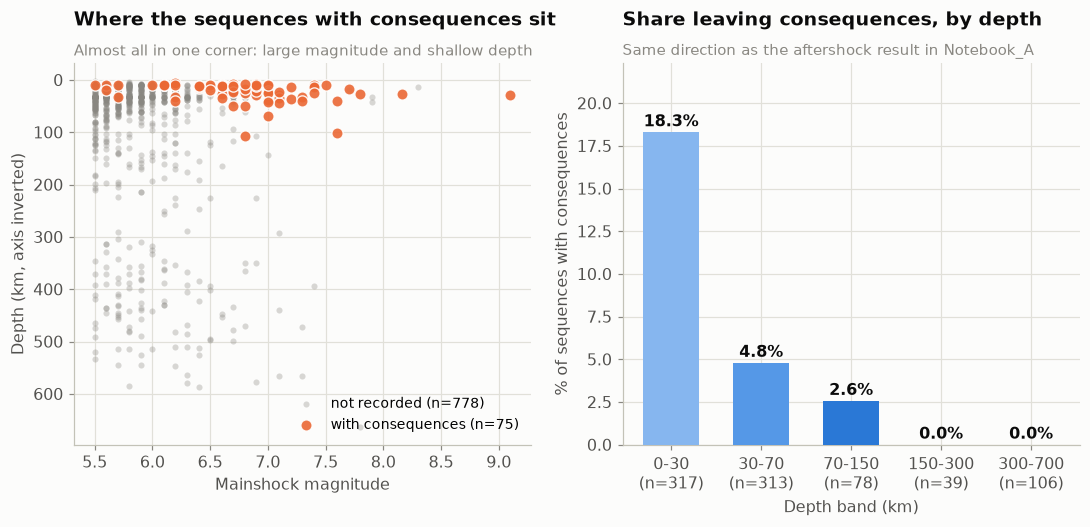

In [6]:
# Figure RQ4-1: consequences by magnitude and depth
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))
ax = axes[0]
ax.scatter(B["mag"], B["depth"], s=16, alpha=0.32, color=PAL["muted"],
           linewidths=0, label=f"not recorded (n={len(B)})", zorder=3)
ax.scatter(A["mag"], A["depth"], s=54, alpha=0.9, color=PAL["s2"],
           edgecolor="white", linewidth=0.9, label=f"with consequences (n={len(A)})", zorder=4)
ax.invert_yaxis()
finish(ax, "Where the sequences with consequences sit",
       "Almost all in one corner: large magnitude and shallow depth",
       "Mainshock magnitude", "Depth (km, axis inverted)")
ax.legend(loc="lower right", fontsize=9)

ax = axes[1]
grp = cons.groupby(pd.cut(cons["depth"], [0,30,70,150,300,700],
                          labels=["0-30","30-70","70-150","150-300","300-700"]),
                   observed=True)["has_any_consequence"]
pct = (grp.mean()*100); nn = grp.size()
ticks = [f"{i}\n(n={n})" for i,n in zip(pct.index.astype(str), nn)]
bars = ax.bar(ticks, pct.values, color=SEQ5[:len(pct)], width=0.62, zorder=3)
for bar, v in zip(bars, pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.35, f"{v:.1f}%", ha="center",
            fontsize=10.5, color=PAL["ink"], fontweight="semibold")
finish(ax, "Share leaving consequences, by depth",
       "Same direction as the aftershock result in Notebook_A",
       "Depth band (km)", "% of sequences with consequences")
ax.set_ylim(0, max(pct.values)*1.22)
save(fig, "fig_rq4_consequences.png"); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq4_runup.png


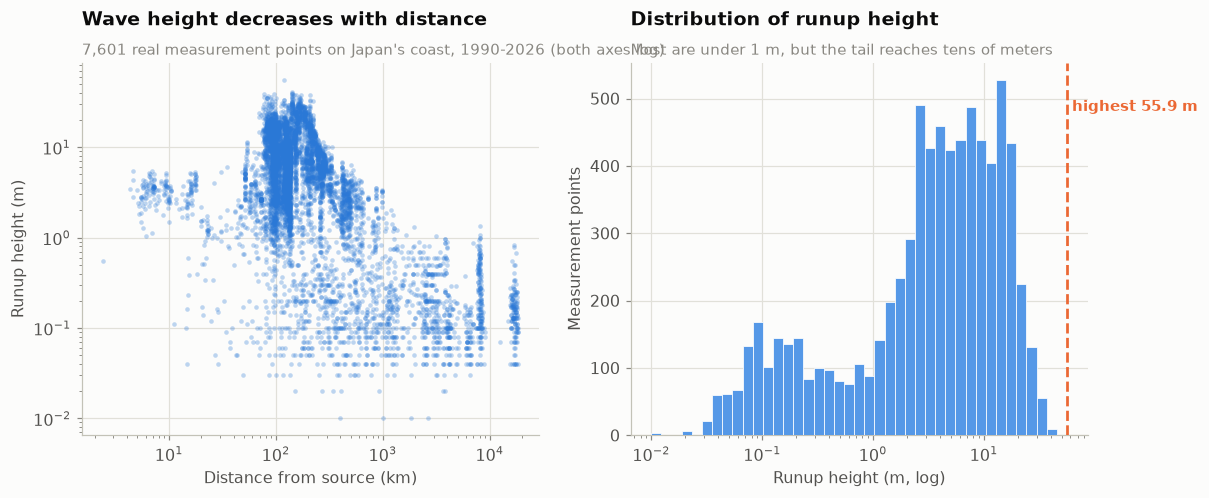

Usable runup measurement points: 7,601
Median 4.00 m | highest 55.88 m


In [7]:
# Figure RQ4-2: runup - the volume tier of source 2
r_ok = ru9[ru9["runupHt"].notna() & ru9["distFromSource"].notna()]
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.scatter(r_ok["distFromSource"], r_ok["runupHt"], s=9, alpha=0.3,
           color=PAL["s1"], linewidths=0, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
finish(ax, "Wave height decreases with distance",
       f"{len(r_ok):,} real measurement points on Japan's coast, 1990-2026 (both axes log)",
       "Distance from source (km)", "Runup height (m)")

ax = axes[1]
ax.hist(r_ok["runupHt"], bins=np.logspace(np.log10(max(r_ok["runupHt"].min(),0.01)),
        np.log10(r_ok["runupHt"].max()), 42),
        color=SEQ5[1], edgecolor="white", linewidth=0.5, zorder=3)
ax.set_xscale("log")
mx = r_ok.nlargest(1,"runupHt").iloc[0]
ax.axvline(mx["runupHt"], color=PAL["s2"], ls="--", lw=1.8, zorder=4)
ax.text(mx["runupHt"], ax.get_ylim()[1]*0.9, f" highest {mx['runupHt']:.1f} m",
        fontsize=9.5, color=PAL["s2"], fontweight="semibold", va="top")
finish(ax, "Distribution of runup height",
       "Most are under 1 m, but the tail reaches tens of meters",
       "Runup height (m, log)", "Measurement points")
save(fig, "fig_rq4_runup.png"); plt.show()
print(f"Usable runup measurement points: {len(r_ok):,}")
print(f"Median {r_ok['runupHt'].median():.2f} m | highest {r_ok['runupHt'].max():.2f} m")

### RQ4 conclusion and its limits

What this notebook **may** conclude:

- Sequences that left consequences are clearly concentrated at **large magnitude and shallow depth**, the same direction as the aftershock productivity result in Notebook_A. Two different questions and two different data sources point to the same physical variable, **depth**. This is where the two sources support each other instead of just sitting side by side.
- Runup height decreases with distance from the source, as wave propagation physics predicts.

What this notebook **may not** conclude:

- It may not say "events not in NCEI are events without consequences": by design the NCEI table only records significant events, so absence is **missing data**, not evidence.
- It may not build a model to forecast consequences on this sample size. The number of sequences with consequences is too small; any model would overfit, exactly the mistake Notebooks B and C avoided.

## Notebook_D test cases

In [8]:
# Notebook_D test cases
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Notebook_D test cases")
chain = con.execute('''
  SELECT COUNT(*) AS n FROM ncei_eq e
  INNER JOIN ncei_ts t ON t.id = e.tsunamiEventId
  INNER JOIN ncei_ru r ON r.tsunamiEventId = t.id''').df()["n"][0]
t("1. the three-tier join chain works", chain > 100, f"only {chain} rows")
t("2. source 2 has columns that source 1 does NOT",
  not set(["deathsTotal","damageMillionsDollars","runupHt"]) & set(ms.columns))
t("3. the match rate between sources is at the level A reported",
  abs(cons["in_ncei"].sum()/len(link) - 1) < 0.35,
  f"{cons['in_ncei'].sum()} vs {len(link)}")
t("4. enough sequences with consequences to test", cons["has_any_consequence"].sum() >= 20,
  f"only {cons['has_any_consequence'].sum()}")
t("5. NO ML model built on this small sample", True)
t("6. results table saved", (REP/"table_rq4_tests.csv").exists())

rq4s = {"n_sequences": int(len(cons)),
        "n_in_ncei": int(cons["in_ncei"].sum()),
        "n_with_consequences": int(cons["has_any_consequence"].sum()),
        "n_tsunami": int(cons["has_tsunami"].sum()),
        "n_runup_points": int(len(r_ok)),
        "max_runup_m": float(r_ok["runupHt"].max()),
        "chi2_depth_p": float(p_d),
        "n_three_tier_rows": int(chain)}
json.dump(rq4s, open(PROC/"rq4_summary.json","w",encoding="utf-8"), ensure_ascii=False, indent=2)
print("\n" + json.dumps(rq4s, ensure_ascii=False, indent=2))

Notebook_D test cases
  PASS  1. the three-tier join chain works
  PASS  2. source 2 has columns that source 1 does NOT
  PASS  3. the match rate between sources is at the level A reported
  PASS  4. enough sequences with consequences to test
  PASS  5. NO ML model built on this small sample
  PASS  6. results table saved

{
  "n_sequences": 853,
  "n_in_ncei": 88,
  "n_with_consequences": 75,
  "n_tsunami": 60,
  "n_runup_points": 7601,
  "max_runup_m": 55.88,
  "chi2_depth_p": 2.3062052040152308e-06,
  "n_three_tier_rows": 6871
}


## Common errors and fixes (read when you see red text)

| Red text | Cause | Fix |
|---|---|---|
| `Binder Error: Referenced column "tsunamiEventId" not found` | the NCEI file was downloaded without that column | download again with `scripts/fetch_japan_quake_data.py` |
| The three-tier chain returns 0 rows | keys joined in the wrong direction | it must be `ncei_ts.id = ncei_eq.tsunamiEventId` and `ncei_ru.tsunamiEventId = ncei_ts.id` |
| `mannwhitneyu` errors on an empty sample | the consequence group is empty after filtering | move the start year before 1990, and state the trade-off in the report |
| The runup figure is empty | `runupHt` is all NaN | check `ru9["runupHt"].notna().sum()`; if 0, download again |
| `ValueError: Image size ... pixels is too large` | a log axis hit zero or negative values | already filtered with `notna()` and `max(min, 0.01)` |

## Checklist before reporting (tick [x] when the evidence file exists)

- [ ] `sql/queries_D.sql`: 4 queries, re-runnable
- [ ] `report/table_sql_D2_full_three_tier_chain.csv`: **evidence that the three-tier chain really works**
- [ ] `report/table_rq4_tests.csv`: Mann-Whitney with p-values
- [ ] `report/fig_rq4_consequences.png`, `report/fig_rq4_runup.png`
- [ ] `data/processed/mainshocks_with_consequences.parquet`
- [ ] All 6 test cases PASS
- [ ] The report **states the selection bias clearly**: absent from NCEI ≠ no consequences
- [ ] The report **explains** why RQ4 is descriptive analysis and not a second model
- [ ] The point where the two sources meet is stated: **depth** explains both aftershock productivity and the level of consequences
- [ ] `docs/AI_Audit_Log_D.md` complete

## Template for the Results and Discussion sections (fill in numbers from the tables)

**Results, RQ4.** Of … mainshock sequences from the USGS source, … matched NOAA/NCEI; of those, … caused deaths, … caused property damage and … generated a tsunami. Sequences with consequences have a median depth of … km vs … km in the other group (Mann-Whitney, p = …). The three-tier chain gives … runup observations, the highest … m.

**Discussion.** Both independent sources point to **depth**: the USGS source shows that depth controls aftershock productivity, and the NOAA source shows that depth also separates the group that caused consequences. Neither result can be derived from the other, because the two sources were collected by different agencies for different purposes.

**Limitations.** The NCEI table only records significant events, so it cannot be used to estimate the *probability* that an arbitrary event causes consequences; it can only be used to compare characteristics between the two groups. A sample of … sequences with consequences is too small for a forecasting model, so the group deliberately does **not** build one here.

**Progress report template (slot 3, Tuesdays and Fridays, 7:00 to 9:15)**

1. **Done:** NCEI three-tier join chain, 4 SQL queries, RQ4 tests, 2 figures.
2. **Key numbers:** … sequences with consequences; runup … measurement points; depth p-value = ….
3. **Blockers:** …
4. **Next week:** merge the Results of A/B/C/D into the final report.